# Классификация опухолей молочной железы: от EDA до kNN

Данные: [Breast Cancer Wisconsin (Diagnostic)](https://www.kaggle.com/uciml/breast-cancer-wisconsin-data) — `data.csv`, 569 объектов, 30 числовых признаков (10 характеристик ядра клетки × три агрегата: `_mean`, `_se`, `_worst`).

**Целевая переменная** `diagnosis`: `M` — злокачественная (malignant), `B` — доброкачественная (benign). За **положительный класс берём `M`** — в медицине важнее не пропустить злокачественную опухоль, поэтому ключевая метрика — recall (чувствительность) по классу M.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
RS = 42

## Часть 1. Разведочный анализ (EDA)

In [2]:
df = pd.read_csv("data.csv")
# 'id' — не признак; 'Unnamed: 32' — пустой столбец-артефакт (хвостовая запятая в csv)
df = df.drop(columns=["id", "Unnamed: 32"])
df["target"] = (df["diagnosis"] == "M").astype(int)   # M=1 (положительный), B=0
feat = df.drop(columns=["diagnosis", "target"])         # только 30 признаков
print("Размер:", df.shape, "| признаков:", feat.shape[1])
df.head()

Размер: (569, 32) | признаков: 30


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [3]:
# Пропуски и баланс классов
print("Пропусков всего:", int(df.isna().sum().sum()))
print(df["diagnosis"].value_counts())
shares = (df["diagnosis"].value_counts(normalize=True) * 100).round(1).to_dict()
print("Доли, %:", shares)

Пропусков всего: 0
diagnosis
B    357
M    212
Name: count, dtype: int64
Доли, %: {'B': 62.7, 'M': 37.3}


Пропусков нет, мусорные столбцы убраны. Классы **несбалансированы умеренно**: B 62.7% / M 37.3%. Это важно помнить: голая accuracy завышена (тривиальный «всё доброкачественное» даёт уже 63%), поэтому опираемся на precision/recall/F1 и ROC-AUC.

In [4]:
# Базовые статистики — по 30 признакам (без служебного target)
feat.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


### Распределения признаков по классам

Признаков 30 (10 × три агрегата). Агрегаты `_mean` и `_worst` в основном сильно скоррелированы между собой (r от 0.70 у `symmetry` до 0.97 у `radius`/`perimeter`, видно ниже на heatmap), поэтому показываем две репрезентативные сетки: `*_mean` и `*_worst` — именно `_worst` чаще всего дают самое сильное разделение классов.

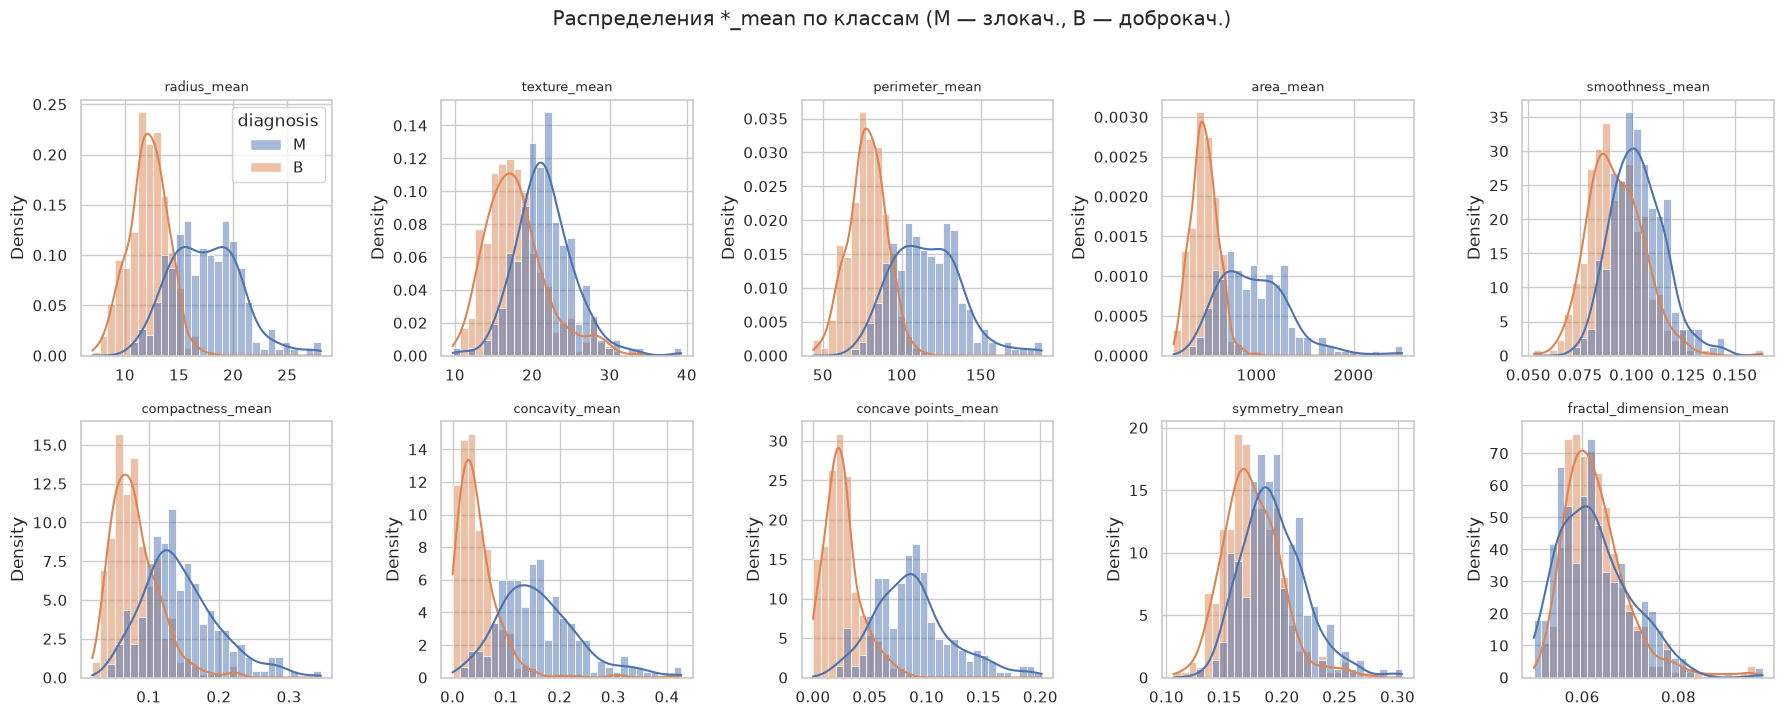

In [5]:
# Распределения *_mean с раскраской по диагнозу
mean_cols = [c for c in feat.columns if c.endswith("_mean")]
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.ravel(), mean_cols):
    sns.histplot(data=df, x=col, hue="diagnosis", bins=30, kde=True,
                 stat="density", common_norm=False, ax=ax, legend=(ax is axes[0, 0]))
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
plt.suptitle("Распределения *_mean по классам (M — злокач., B — доброкач.)", y=1.02)
plt.tight_layout()
plt.show()

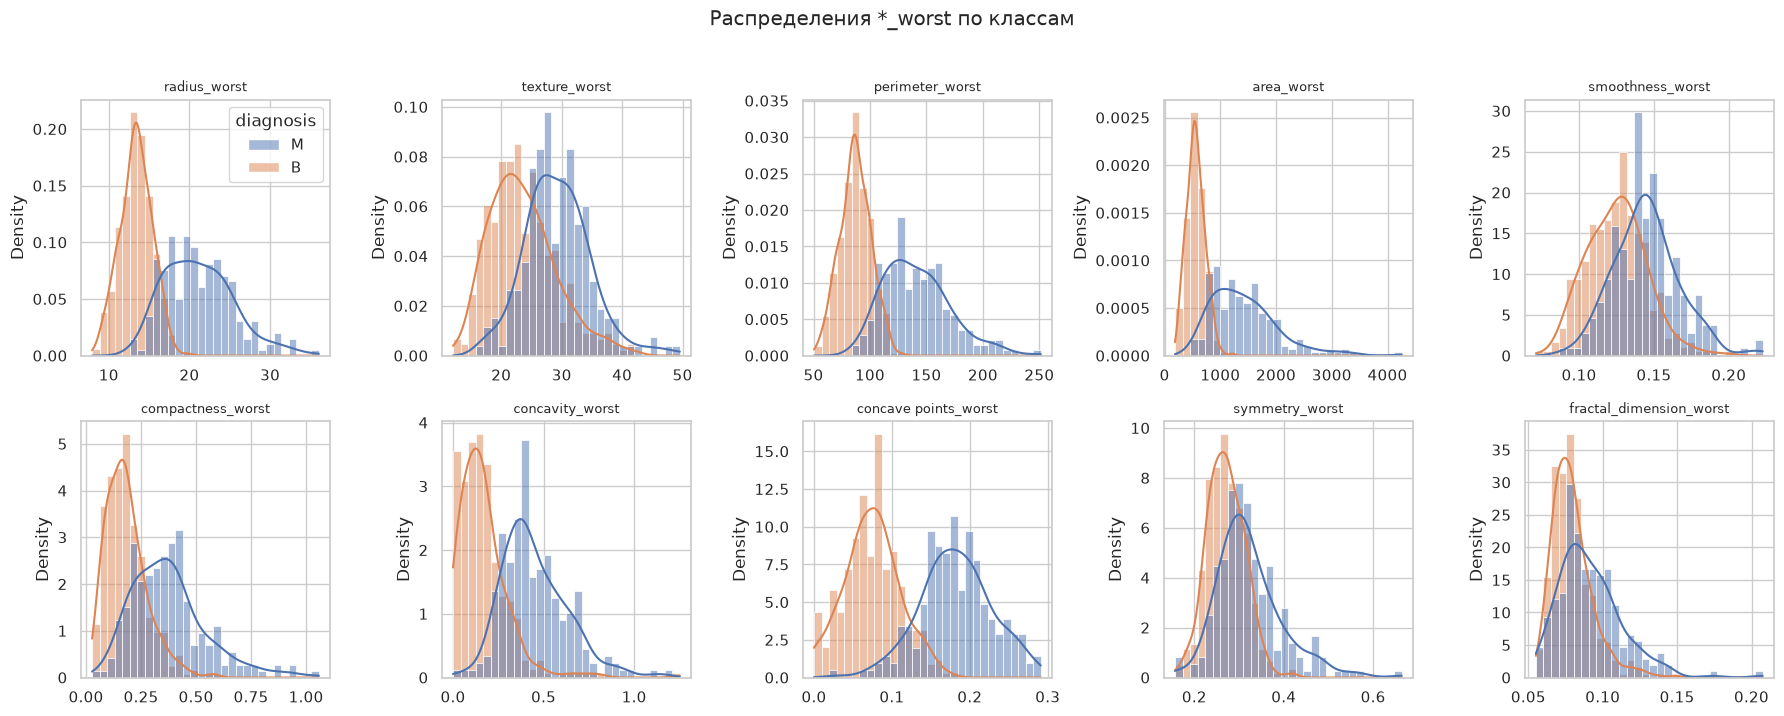

In [6]:
# Распределения *_worst — лучше всего разделяют классы
worst_cols = [c for c in feat.columns if c.endswith("_worst")]
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.ravel(), worst_cols):
    sns.histplot(data=df, x=col, hue="diagnosis", bins=30, kde=True,
                 stat="density", common_norm=False, ax=ax, legend=(ax is axes[0, 0]))
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
plt.suptitle("Распределения *_worst по классам", y=1.02)
plt.tight_layout()
plt.show()

По многим признакам (`radius`, `perimeter`, `area`, `concave points`, `concavity`) распределения классов заметно **разъезжаются**: у злокачественных опухолей значения систематически выше, и у большинства из них агрегат `_worst` разделяет сильнее `_mean` (исключение — `concavity`, где чуть сильнее `_mean`: |r с target| 0.70 против 0.66). По `smoothness`, `symmetry`, `fractal_dimension` классы перекрываются заметно сильнее — эти признаки разделяют слабо (|r с target| ~0.32–0.42 у `_worst`; у `fractal_dimension_mean` и вовсе ≈0).

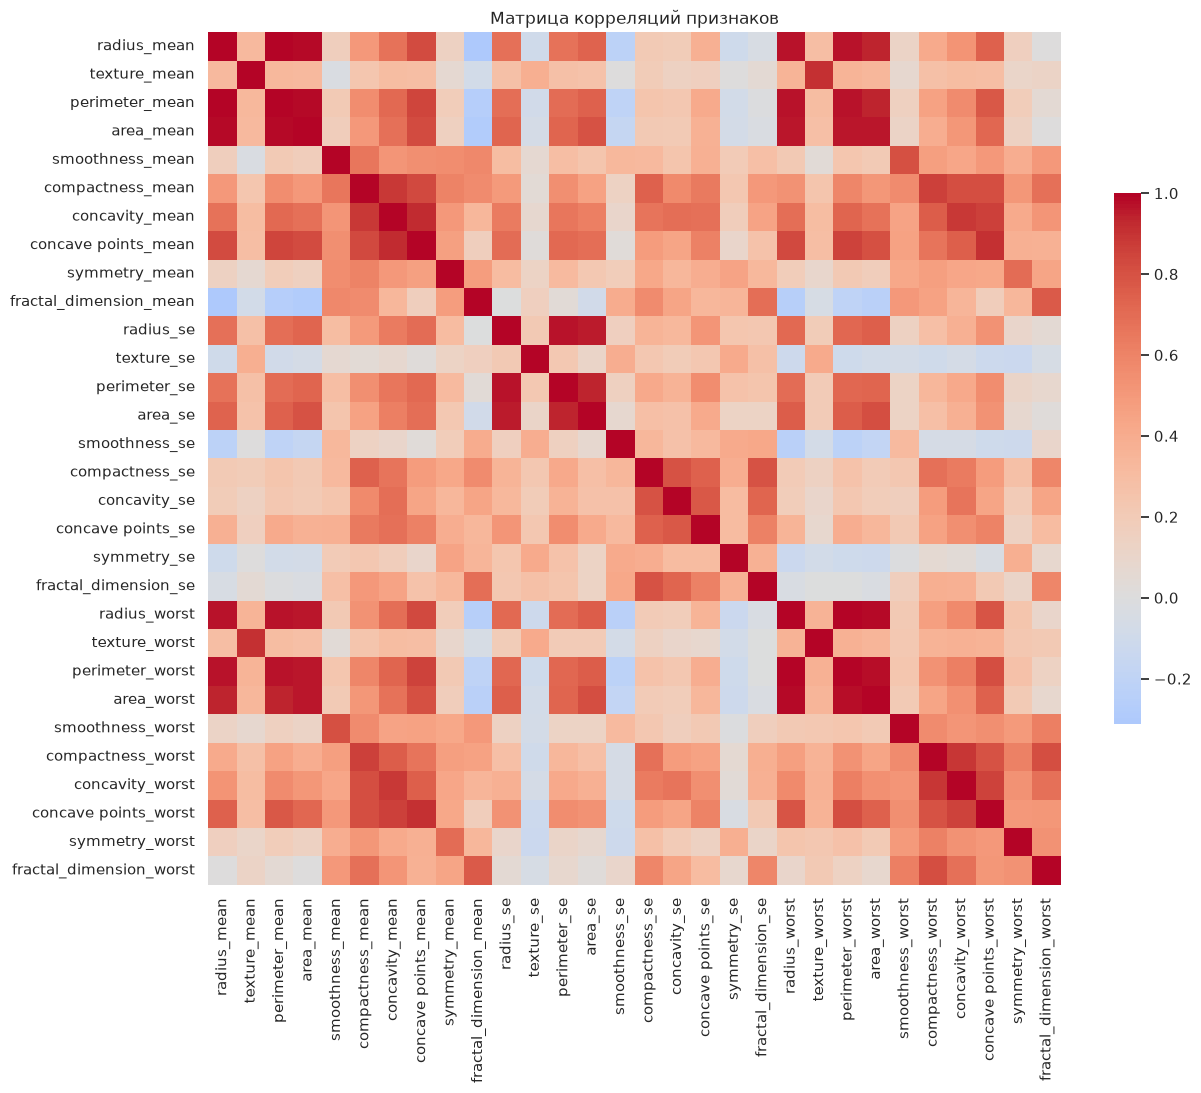

In [7]:
# Матрица корреляций 30 признаков
plt.figure(figsize=(13, 11))
sns.heatmap(feat.corr(), cmap="coolwarm", center=0, square=True,
            xticklabels=True, yticklabels=True, cbar_kws={"shrink": .6})
plt.title("Матрица корреляций признаков")
plt.tight_layout()
plt.show()

In [8]:
# Пары с |r| > 0.85 — кандидаты на удаление в бонусе (мультиколлинеарность).
# Сортируем по ТОЧНОМУ значению, округляем только при печати.
corr_abs = feat.corr().abs()
cols = corr_abs.columns
pairs = [(cols[i], cols[j], corr_abs.iloc[i, j])
         for i in range(len(cols)) for j in range(i + 1, len(cols))
         if corr_abs.iloc[i, j] > 0.85]
pairs.sort(key=lambda t: -t[2])
print(f"Пар с |r| > 0.85: {len(pairs)}. Топ-10:")
for a, b, r in pairs[:10]:
    print(f"  |r|={r:.3f}  {a}  ~  {b}")

Пар с |r| > 0.85: 29. Топ-10:
  |r|=0.998  radius_mean  ~  perimeter_mean
  |r|=0.994  radius_worst  ~  perimeter_worst
  |r|=0.987  radius_mean  ~  area_mean
  |r|=0.987  perimeter_mean  ~  area_mean
  |r|=0.984  radius_worst  ~  area_worst
  |r|=0.978  perimeter_worst  ~  area_worst
  |r|=0.973  radius_se  ~  perimeter_se
  |r|=0.970  perimeter_mean  ~  perimeter_worst
  |r|=0.970  radius_mean  ~  radius_worst
  |r|=0.969  perimeter_mean  ~  radius_worst


Ярко выражена **геометрическая мультиколлинеарность**: `radius`, `perimeter`, `area` почти функционально связаны (perimeter и area выводятся из радиуса), |r| до 0.998. Проверим на scatter, действительно ли зависимость линейна.

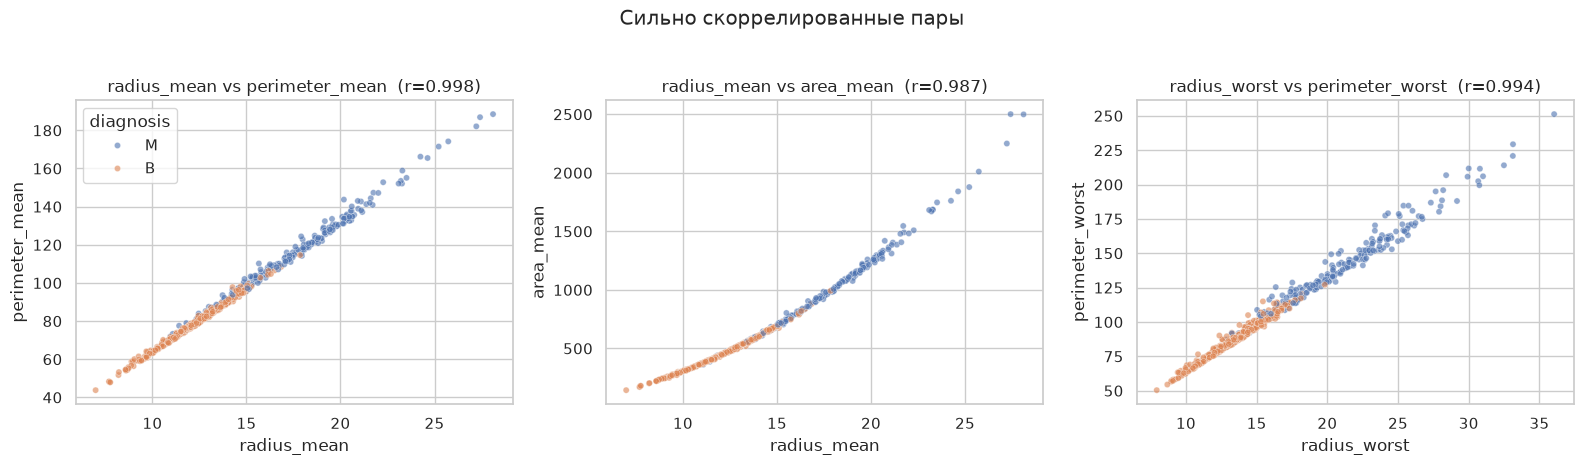

In [9]:
# Scatter для самых скоррелированных пар, окраска по классу.
# В подписи — ЗНАКОВЫЙ r (все эти пары положительные).
signed = feat.corr()
top_pairs = [("radius_mean", "perimeter_mean"), ("radius_mean", "area_mean"),
             ("radius_worst", "perimeter_worst")]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (a, b) in zip(axes, top_pairs):
    sns.scatterplot(data=df, x=a, y=b, hue="diagnosis", alpha=0.6, s=20, ax=ax,
                    legend=(ax is axes[0]))
    ax.set_title(f"{a} vs {b}  (r={signed.loc[a, b]:.3f})")
plt.suptitle("Сильно скоррелированные пары", y=1.03)
plt.tight_layout()
plt.show()

`radius ~ perimeter` — практически идеальная **прямая** (perimeter ≈ 2πr), `radius ~ area` — слегка выгнута (area ≈ πr², квадратичная зависимость, но в наблюдаемом диапазоне почти линейна). Такие признаки дублируют информацию: в евклидовом расстоянии kNN они утраивают вес «размерного» фактора, а для логистической регрессии (бонус) мультиколлинеарность прямо вредна. Как это скажется на kNN (размер — сильный сепаратор, так что дублирование может и помочь, и помешать) — **проверим экспериментом в Части 2**, поэтому пока это гипотеза, а не вывод.

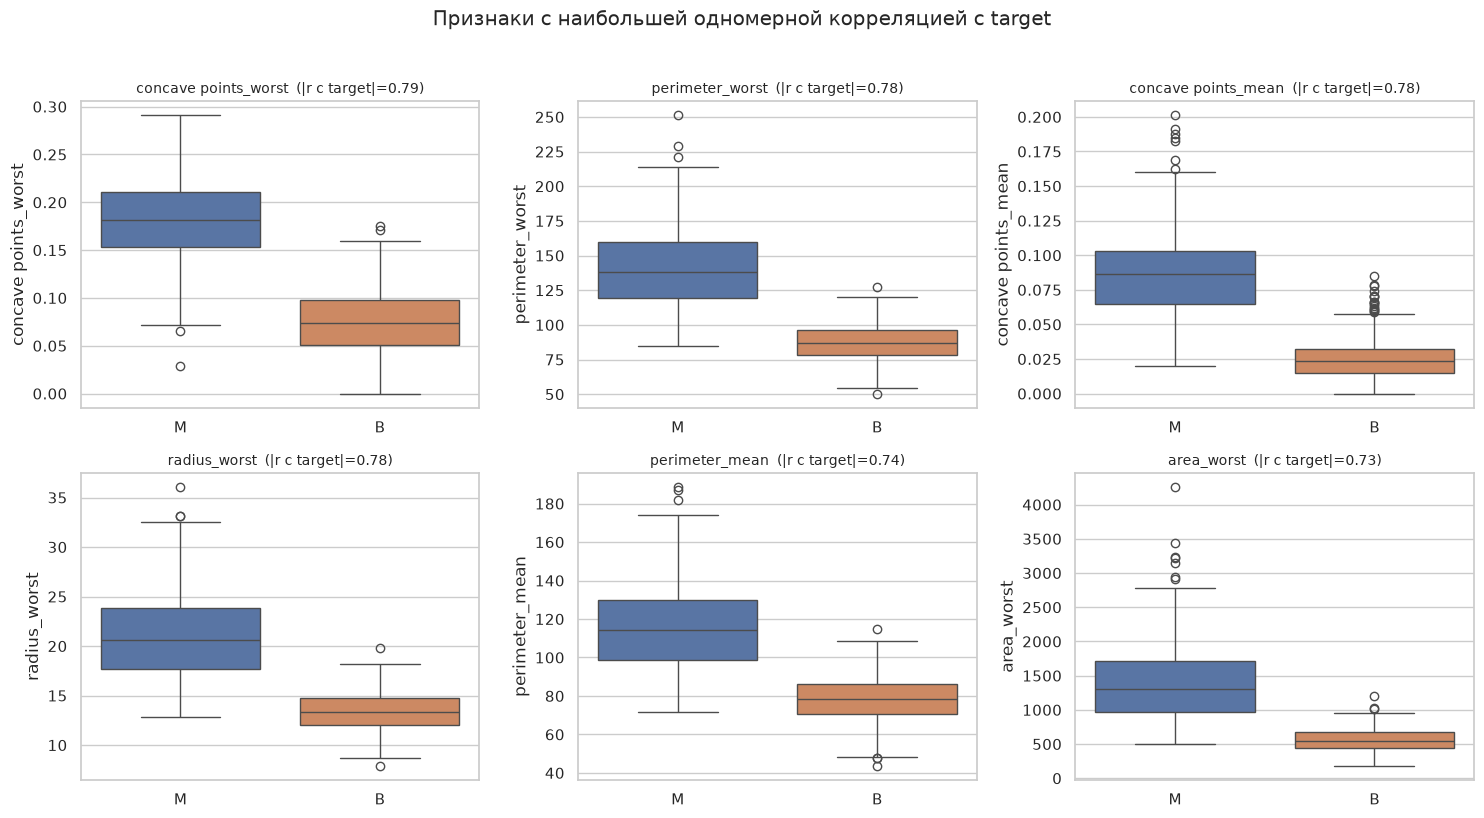

Топ-6 по |корр с target|:
concave points_worst    0.794
perimeter_worst         0.783
concave points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
area_worst              0.734


In [10]:
# Одномерная разделяющая способность: |корреляция признака с target| (point-biserial)
y = df["target"]
sep = feat.apply(lambda c: np.corrcoef(c, y)[0, 1]).abs().sort_values(ascending=False)
best = sep.head(6).index
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), best):
    sns.boxplot(data=df, x="diagnosis", y=col, ax=ax, hue="diagnosis", legend=False)
    ax.set_title(f"{col}  (|r с target|={sep[col]:.2f})", fontsize=10)
    ax.set_xlabel("")
plt.suptitle("Признаки с наибольшей одномерной корреляцией с target", y=1.02)
plt.tight_layout()
plt.show()
print("Топ-6 по |корр с target|:")
print(sep.head(6).round(3).to_string())

**Итоги EDA:**
- Данные чистые, 30 числовых признаков, целевая — бинарная, классы 63/37.
- Наибольшая **одномерная** разделяющая способность (по |корр с target|): `concave points_worst` (0.79), `perimeter_worst` (0.78), `concave points_mean` (0.78), `radius_worst` (0.78), `perimeter_mean` (0.74), `area_worst` (0.73). У всех шести **межквартильные диапазоны (IQR) классов не пересекаются** — по boxplots видно чистое разделение медиан и «коробок». Логично: злокачественные опухоли крупнее и с более выраженной вогнутостью контура.
- Оговорка: это ранжирование — **описательная статистика по всей выборке**, а не отбор признаков для модели. Одномерная корреляция ловит только линейную маржинальную связь (признак, слабый в одиночку, может быть силён в комбинации); реальную полезность покажет модель. Любой supervised-отбор в Части 2 будем делать только по train, чтобы не занести утечку.
- Сильная мультиколлинеарность в группе `radius/perimeter/area` (все три агрегата), 29 пар с |r|>0.85 — учтём в бонусе.
- Признаки в **разных масштабах** (`area_worst` ~ сотни-тысячи, `smoothness` ~ 0.1) → перед kNN обязательна стандартизация (Часть 2).

## Часть 2. Моделирование при помощи kNN

**Зачем стандартизация именно здесь.** kNN относит объект к классу по большинству среди $k$ ближайших соседей, а «близость» меряется евклидовым расстоянием — суммой квадратов разностей по всем признакам. Поэтому признак с бо́льшим численным масштабом доминирует: у нас `area_worst` измеряется сотнями-тысячами, а `smoothness_mean` — десятыми долями, и без приведения к общему масштабу расстояние определялось бы почти только площадью/периметром. `StandardScaler` вычитает среднее и делит на СКО, уравнивая вклад признаков.

**Против утечки.** Скейлер обучаем (`fit`) только на train и держим внутри `Pipeline` — тогда при кросс-валидации на каждом фолде масштаб считается по обучающей части фолда, а не по всем данным.

In [11]:
X = df.drop(columns=["diagnosis", "target"])
y = df["target"]                       # M=1 (положительный класс)

# 30% в тест, стратификация по классу (дисбаланс 63/37 сохраняем в обеих частях)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RS, stratify=y)
print("train:", X_train.shape, "| test:", X_test.shape)
print(f"Доля M — train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")

train: (398, 30) | test: (171, 30)
Доля M — train: 0.372, test: 0.374


In [12]:
def evaluate(name, estimator, X, y):
    """Метрики бинарной классификации (положительный класс = M)."""
    pred = estimator.predict(X)
    proba = estimator.predict_proba(X)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
        "roc_auc": roc_auc_score(y, proba),
    }

### kNN «из коробки»

Дефолтный `KNeighborsClassifier` — это $k=5$, равные веса соседей, евклидова метрика. Стандартизация — внутри пайплайна.

{'accuracy': 0.965, 'precision': 1.0, 'recall': 0.906, 'f1': 0.951, 'roc_auc': 0.988}


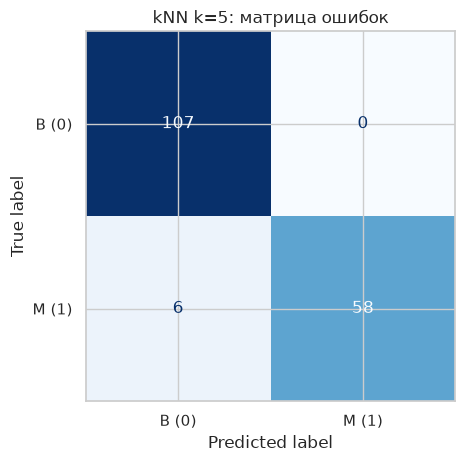

FN (пропущенных злокачественных): 6


In [13]:
knn_base = Pipeline([("scaler", StandardScaler()),
                     ("knn", KNeighborsClassifier())])  # k=5 по умолчанию
knn_base.fit(X_train, y_train)

res_base = evaluate("kNN из коробки (k=5)", knn_base, X_test, y_test)
print({k: round(v, 3) for k, v in res_base.items() if k != "model"})

cm = confusion_matrix(y_test, knn_base.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=["B (0)", "M (1)"]).plot(
    cmap="Blues", colorbar=False)
plt.title("kNN k=5: матрица ошибок")
plt.show()
print("FN (пропущенных злокачественных):", cm[1, 0])

«Из коробки» kNN уже очень силён: accuracy 0.965, **precision 1.0** (ни одного ложного «злокачественного»), recall 0.906, F1 0.951, ROC-AUC 0.988. Из 64 злокачественных пропущено 6 (FN) — для медзадачи именно эти FN самые дорогие.

### Настройка числа соседей на кросс-валидации

Перебираем $k$ от 1 до 30 на стратифицированной 5-fold CV **по train**. Основная метрика подбора — **F1**: она балансирует precision и recall, что уместно при дисбалансе классов и в медицине. Отдельно покажем, что подбор по ROC-AUC уводит к другому $k$ с худшим recall.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
grid = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])
k_range = list(range(1, 31))

gs_f1 = GridSearchCV(grid, {"knn__n_neighbors": k_range},
                     scoring="f1", cv=cv, n_jobs=-1).fit(X_train, y_train)
gs_auc = GridSearchCV(grid, {"knn__n_neighbors": k_range},
                      scoring="roc_auc", cv=cv, n_jobs=-1).fit(X_train, y_train)
k_f1 = gs_f1.best_params_["knn__n_neighbors"]
k_auc = gs_auc.best_params_["knn__n_neighbors"]
print(f"Лучшее k по F1: {k_f1} | CV F1 = {gs_f1.best_score_:.4f}")
print(f"Лучшее k по ROC-AUC: {k_auc} | CV AUC = {gs_auc.best_score_:.4f}")

Лучшее k по F1: 7 | CV F1 = 0.9537
Лучшее k по ROC-AUC: 26 | CV AUC = 0.9895


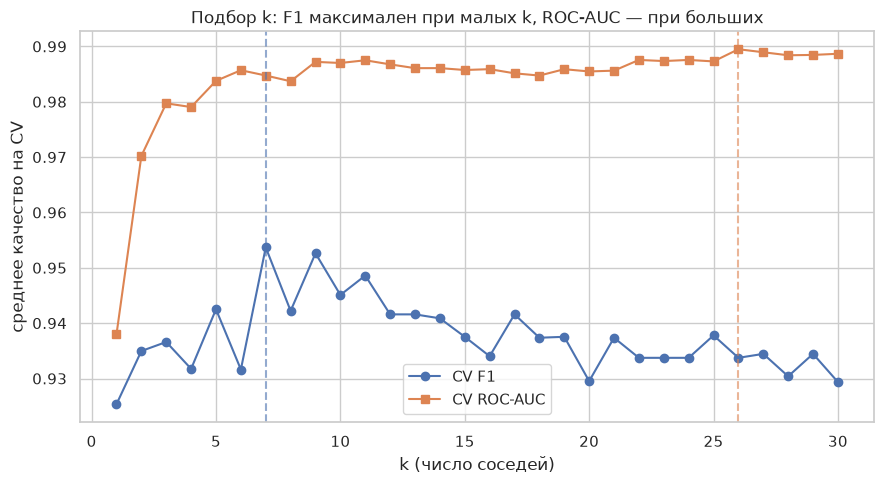

In [15]:
plt.figure(figsize=(9, 5))
plt.plot(k_range, gs_f1.cv_results_["mean_test_score"], "o-", label="CV F1")
plt.plot(k_range, gs_auc.cv_results_["mean_test_score"], "s-", label="CV ROC-AUC")
plt.axvline(k_f1, color="C0", ls="--", alpha=.6)
plt.axvline(k_auc, color="C1", ls="--", alpha=.6)
plt.xlabel("k (число соседей)")
plt.ylabel("среднее качество на CV")
plt.title("Подбор k: F1 максимален при малых k, ROC-AUC — при больших")
plt.legend()
plt.tight_layout()
plt.show()

F1 на CV максимален при **малом $k$** (пик около $k=7$), а ROC-AUC растёт к **большим $k$** ($k=26$). Причина не в калибровке (по Brier на тесте k=26 даже чуть хуже: 0.033 против 0.031 у k=5), а в **дробности** оценок вероятности: у $k=26$ — 26 различных значений `predict_proba` против 6 у $k=5$, что даёт более тонкое ранжирование объектов → выше AUC. При этом при пороге 0.5 recall по M падает: чем больше соседей, тем чаще в окрестности перевешивает мажоритарный класс B (63%), и пограничные злокачественные уходят в B (FN 6 → 9). Это компромисс между ранжированием (AUC) и рабочей точкой (recall при фиксированном пороге).

In [16]:
res_f1 = evaluate(
    f"kNN тюнинг по F1 (k={k_f1})", gs_f1.best_estimator_, X_test, y_test)
res_auc = evaluate(
    f"kNN тюнинг по AUC (k={k_auc})", gs_auc.best_estimator_, X_test, y_test)
comparison = pd.DataFrame([res_base, res_f1, res_auc]).set_index("model").round(3)
comparison

,accuracy,precision,recall,f1,roc_auc
model,,,,,
kNN из коробки (k=5),0.965,1.0,0.906,0.951,0.988
kNN тюнинг по F1 (k=7),0.965,1.0,0.906,0.951,0.987
kNN тюнинг по AUC (k=26),0.947,1.0,0.859,0.924,0.998


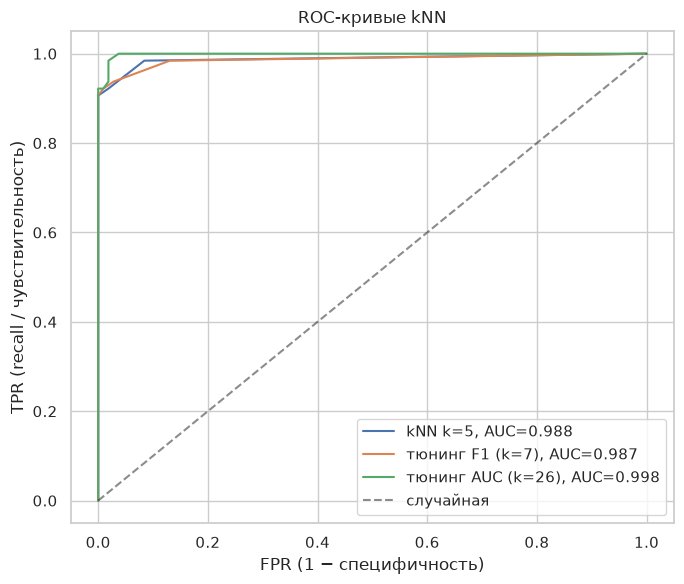

In [17]:
plt.figure(figsize=(7, 6))
models = [("kNN k=5", knn_base),
          (f"тюнинг F1 (k={k_f1})", gs_f1.best_estimator_),
          (f"тюнинг AUC (k={k_auc})", gs_auc.best_estimator_)]
for name, est in models:
    proba = est.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name}, AUC={roc_auc_score(y_test, proba):.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=.5, label="случайная")
plt.xlabel("FPR (1 − специфичность)")
plt.ylabel("TPR (recall / чувствительность)")
plt.title("ROC-кривые kNN")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Стало ли лучше после настройки?

**Практически нет.** kNN «из коробки» уже даёт почти идеальное качество (AUC 0.99, F1 0.95, precision 1.0), поэтому пространства для улучшения мало:

- Подбор по **F1** даёт $k=7$ — на тесте метрики совпадают с baseline (acc 0.965, recall 0.906, F1 0.951): дефолтный $k=5$ уже был около оптимума.
- Подбор по **ROC-AUC** даёт $k=26$ — формально повышает AUC (0.988 → 0.998), но снижает recall (0.906 → 0.859), то есть пропускает **больше** злокачественных опухолей. Для диагностики это ухудшение, а не улучшение, несмотря на «более высокую» интегральную метрику.

**Вывод:** настройка $k$ не улучшила модель в том, что важно для диагностики (recall по злокачественным); ценность этапа — понимание, что дефолт близок к оптимуму и что выбор метрики оптимизации напрямую диктует рабочую точку. Для этой задачи разумно оставить небольшое $k$ (5–7) и при необходимости отдельно настраивать порог классификации под целевой recall.